# CAB320 Assignment 2 - Transfer Learning
Anthony Vanderkop, Thierry Peynot, Frederic Maire (Jupyter Notebook template: 2025)


## Instructions:
The functions and classes defined in this module will be called by the marker without modification. 
You should complete the functions and classes according to their specified interfaces.

No partial marks will be awarded for functions that do not meet the specifications of the interfaces.


In [32]:
### LIBRARY IMPORTS ###
import os
import numpy as np

import keras.applications as ka
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support
import tensorflow as tf

## Task 1
Implement the my_team()function 

In [8]:
def my_team():
    '''
    Return the list of the team members of this assignment submission as a list
    of triplet of the form (student_number, first_name, last_name)
    
    '''
    return [('n0827053', 'Ashley', 'Longhurst'), ('Kyle', 'Ruter'), ('n12393631', 'Katherine', 'Newman')] 

In [9]:
my_team()

[('n0827053', 'Ashley', 'Longhurst'),
 ('Kyle', 'Ruter'),
 ('n12393631', 'Katherine', 'Newman')]

## Task 2
Download the small_flower_dataset from Canvas and load the data

In [10]:
def load_data(path):
    '''
    Load in the dataset from its home path. Path should be a string of the path
    to the home directory the dataset is found in. Should return a numpy array
    with paired images and class labels.
    
    Insert a more detailed description here.
    '''
    subfolders = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']
    
    images = []
    labels = []
    
    label_map = {
        'daisy': 0,
        'dandelion': 1,
        'roses': 2,
        'tulips': 3,
        'sunflowers': 4
    }
    
    for subfolder in subfolders:
        full_path = os.path.join(path, subfolder)   # uses the argument now
        image_files = os.listdir(full_path)
    
        for img_file in image_files:
            img_path = os.path.join(full_path, img_file)
            img = cv2.imread(img_path)
    
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (128, 128))
                images.append(img)
                labels.append(label_map[subfolder])
    
    X = np.array(images)
    y = np.array(labels)
    
    print("All images shape:", X.shape)
    print("All labels shape:", y.shape)
    print("Class labels:", label_map)
    dataset = np.array(list(zip(X, y)), dtype=object)
    return dataset
   

In [11]:
dataset = load_data('./small_flower_dataset')
X = np.array([item[0] for item in dataset])
Y = np.array([item[1] for item in dataset])

All images shape: (1000, 128, 128, 3)
All labels shape: (1000,)
Class labels: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'tulips': 3, 'sunflowers': 4}


In [12]:
"""
We want to have a look at how the images are set up
"""

print(X[0][0]) # The first row of pixels just to look at the values 0 - 255. Each pixel RGB values
print(len(X[0][0])) # 128 - First row has 128. So all looks ok. 
                    # Will we need to resize or normalise for the CNN part?

[[146 145 128]
 [166 165 141]
 [ 86  89  56]
 [136 132 104]
 [123 122  91]
 [107 107  74]
 [137 134  97]
 [ 93  89  61]
 [171 164 148]
 [147 142 115]
 [139 131 102]
 [171 165 138]
 [167 161 139]
 [113 110  84]
 [137 138 109]
 [101  99  65]
 [ 94 100  67]
 [130 119  98]
 [112 109  75]
 [164 151 130]
 [169 165 138]
 [153 145 123]
 [160 154 132]
 [168 164 133]
 [107 105  65]
 [151 143 120]
 [127 126  94]
 [107 107  70]
 [181 177 137]
 [ 91  86  44]
 [ 71  78  38]
 [190 179 149]
 [ 77  90  39]
 [124 127  85]
 [121 119  86]
 [185 183 150]
 [169 154 120]
 [145 140 108]
 [207 200 164]
 [155 152 117]
 [175 170 129]
 [205 199 159]
 [182 172 141]
 [198 185 152]
 [130 126  76]
 [107 103  65]
 [199 189 156]
 [128 120  86]
 [192 186 155]
 [219 211 171]
 [185 181 146]
 [165 158 118]
 [151 143 108]
 [ 65  72  20]
 [120 116  74]
 [172 166 125]
 [177 170 131]
 [ 56  63  20]
 [125 116  80]
 [214 205 176]
 [223 214 179]
 [221 212 180]
 [160 151 119]
 [176 169 137]
 [213 208 181]
 [187 186 148]
 [136 128 

In [13]:
"""
A quick check to see how the data is structured and to see if
class labels a fairly balanced. This code block wont be imcluded in the final submission.
"""
print(np.unique(Y, return_counts=True)) # We can see there are 200 of each

(array([0, 1, 2, 3, 4]), array([200, 200, 200, 200, 200]))


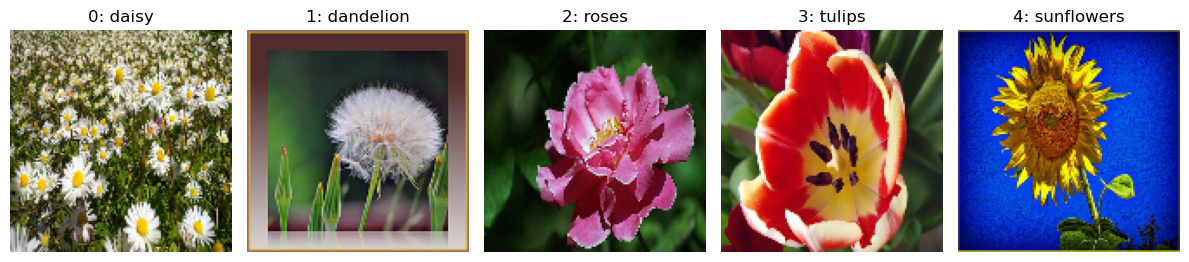

In [14]:
"""
This code block is just to see the load has worked
and to see if the labels and the images are matched.
It probably wont be included in the final submission
"""

label_map_check = {
    0: 'daisy',
    1: 'dandelion',
    2: 'roses',
    3: 'tulips',
    4: 'sunflowers'
}

plt.figure(figsize=(12, 4))

for flower_label in range(5):
    for i in range(len(dataset)):
        image = dataset[i][0]
        label = dataset[i][1]

        if label == flower_label:
            plt.subplot(1, 5, flower_label + 1)
            plt.imshow(image)
            plt.title(f"{label}: {label_map_check[label]}")
            plt.axis('off')
            break

plt.tight_layout()
plt.show()

## Task 3
Prepare your training, validation and test sets for the non-accelerated version of transfer learning.

In [15]:
def split_data(X, Y, train_fraction, randomize=False, eval_set=True):
    """
    Split the data into training and testing sets. If eval_set is True, also create
    an evaluation dataset. There should be two outputs if eval_set there should
    be three outputs (train, test, eval), otherwise two outputs (train, test).
    
    To see what type train, test, and eval should be, refer to the inputs of 
    transfer_learning().
    
    This uses sklearn's train test split library. See https://scikit-learn.org/stable/modules/generated/
    sklearn.model_selection.train_test_split.html. The output type conforms to the transfer_learning()
    input data type (a tuple of images and labels : eg (images, labesl)). Random state is utilised for reproducability
    initially among team members and the randomise is used to ensure no class imbalance.
    """
    if eval_set:
        # First split: training set and leftover set
        X_train, X_temp, Y_train, Y_temp = train_test_split(
            X,
            Y,
            train_size=train_fraction,
            shuffle=randomize,
            random_state=42
        )

        # Second split: split leftover data equally into test and eval sets
        X_test, X_eval, Y_test, Y_eval = train_test_split(
            X_temp,
            Y_temp,
            test_size=0.5,
            shuffle=randomize,
            random_state=42
        )

        train = (X_train, Y_train)
        test = (X_test, Y_test)
        eval_data = (X_eval, Y_eval)

        return train, test, eval_data

    else:
        X_train, X_test, Y_train, Y_test = train_test_split(
            X,
            Y,
            train_size=train_fraction,
            shuffle=randomize,
            random_state=42
        )

        train = (X_train, Y_train)
        test = (X_test, Y_test)

        return train, test

In [16]:
def get_sets(X, Y, train_ratio=0.8, randomize=True, use_eval=True):
    '''
    Split data into train/test sets, with an optional evaluation set.
    '''
    if use_eval:
        train_set, test_set, eval_set = split_data(
            X, Y, train_ratio, randomize=randomize, eval_set=True
        )
    else:
        train_set, test_set = split_data(
            X, Y, train_ratio, randomize=randomize, eval_set=False
        )
        eval_set = None
    return train_set, test_set, eval_set

In [17]:
train_set, test_set, eval_set = get_sets(X, Y, train_ratio=0.8, randomize=True, use_eval=True)

In [18]:
"""
Plots to show how the train test split function worked 
and if any class imbalance exists in the sets. This can be talked
about in the text block below latwer on. 
"""
def plot_class_distributions(train_set, test_set, eval_set=None, label_map=None):
 
    sets = [('Training Set', train_set[1]), ('Testing Set', test_set[1])]
    if eval_set is not None:
        sets.append(('Evaluation Set', eval_set[1]))

    n = len(sets)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    if n == 1:
        axes = [axes]

    for ax, (title, y) in zip(axes, sets):
        unique, counts = np.unique(y, return_counts=True)
        names = [label_map[i] for i in unique] if label_map else unique
        ax.bar(names, counts)
        ax.set_title(f'{title} (n={len(y)})')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

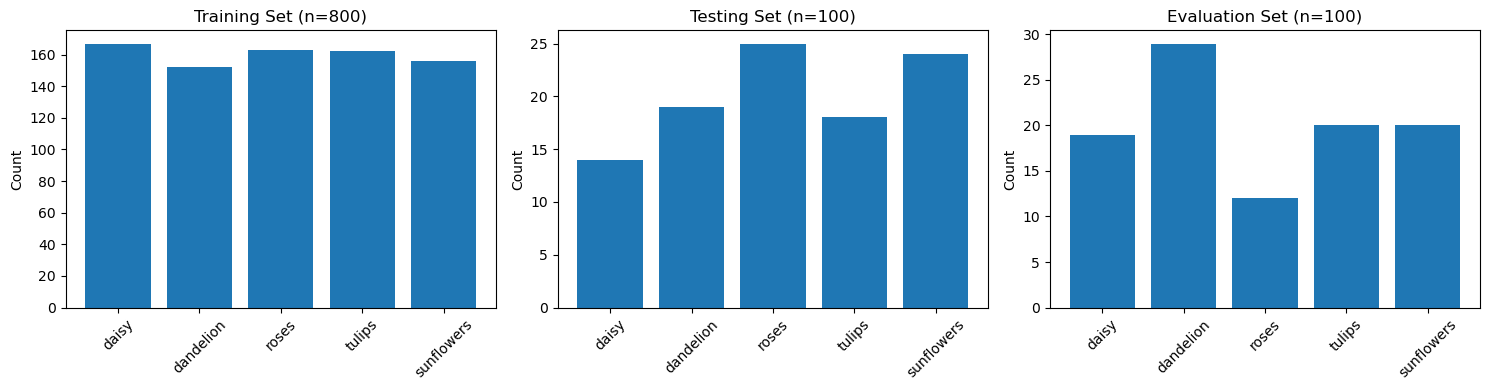

In [19]:
plot_class_distributions(train_set, test_set, eval_set, label_map=label_map_check)

Report: Include details of how you have split the data to perform this training. Ensure the split is reasonable and does not introduce class imbalance during training

Insert details here.


## Task 4
Using the tf.keras.applications module download a pretrained MobileNetV2 network. 

In [20]:
def load_model():
    '''
    Load in a model using the tf.keras.applications model and return it.
    Insert a more detailed description here
    '''
    model = tf.keras.applications.MobileNetV2(
    weights='imagenet'
    )

    return model    

In [21]:
model = load_model()
model.summary()

2026-05-23 15:34:24.540598: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

(224, 224, 3)


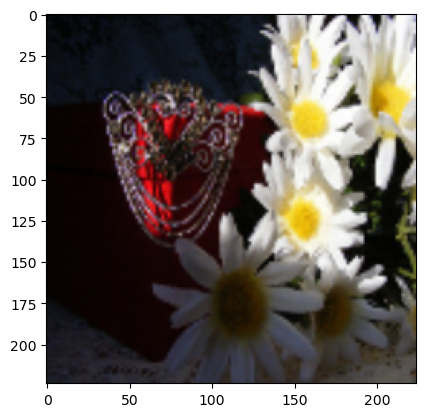

In [22]:
"""
Having a look at the pretrained model, we can see that the input layer is 224x224x3.
Our images are 128x128x3. As the model is pretrained on 224 images we shouldn't change the weights in the
actual model. We need to resize our own images to conform to the input size of the pretrained model. Also, have to
try and find what sort of data the MobileNetV2 was trained on. eg was it (0-255) or something different.
It was (-1 : +1). Quote from Keras page " Note: each TF-Keras Application expects a specific 
kind of input preprocessing. For MobileNet, call tf.keras.applications.mobilenet.preprocess_input on 
your inputs before passing them to the model. mobilenet.preprocess_input will scale input pixels between -1 and 1."
"""

# Resize all sets of images (Train, Test, Val)

resized_train = tf.image.resize(train_set[0], [224, 224])
resized_test = tf.image.resize(test_set[0], [224, 224])
resized_val = tf.image.resize(eval_set[0], [224, 224])

# Check to see if it worked
print(resized_train[0].shape)

# What does it look like
plt.imshow(resized_train[0] / 255.0)

# Rescale images
final_train_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_train)
final_test_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_test)
final_val_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_val)

# Add the labels back
final_train = (final_train_imgs, train_set[1])
final_test  = (final_test_imgs,  test_set[1])
final_val   = (final_val_imgs,   eval_set[1])

In [23]:
"""
This is for Task 5
"""
# Get the output of the previous layer (Global Average Pooling)
previous_layer_output = model.layers[-2].output

# Add required final layer
new_final_layer = tf.keras.layers.Dense(5, activation='softmax')(previous_layer_output)

# Create the new mmodel
new_model = tf.keras.Model(inputs=model.input, outputs=new_final_layer)

# Freeze training on the original layers
for layer in new_model.layers[:-1]:
    layer.trainable = False

new_model.summary()

# From the last line of the summary we can see that only the last layer is trainable (6405).

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Task 5
Replace the last layer of the downloaded neural network with a Dense layer of the appropriate shape for the 5 classes of the small flower dataset {(x1,t1), (x2,t2),..., (xm,tm)}.

## Task 6
Compile and train your model with an SGD optimizer using the following parameters learning_rate=0.01, momentum=0.0, nesterov=False. (NB: The SGD class description can be found at https://keras.io/api/optimizers/sgd/  )

In [24]:
def transfer_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform standard transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    # Unpack the images and labels
    train_images, train_labels = final_train
    eval_images, eval_labels = final_val
    learning_rate, momentum, nesterov = parameters

    # Set up the optimiser
    optimizer = tf.keras.optimizers.SGD(
        learning_rate=learning_rate,
        momentum=momentum,
        nesterov=nesterov
    )

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train the model
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(eval_images, eval_labels),
        epochs=30,
        batch_size=32,
        verbose=1
    )

    return model, history

In [25]:
# model = transfer_learning()
parameters = (0.001, 0.9, True)

model, history = transfer_learning(final_train, final_val, new_model, parameters)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - accuracy: 0.4563 - loss: 1.3369 - val_accuracy: 0.6600 - val_loss: 1.0115
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.7362 - loss: 0.7775 - val_accuracy: 0.7400 - val_loss: 0.7023
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.8150 - loss: 0.6005 - val_accuracy: 0.8100 - val_loss: 0.5813
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.8400 - loss: 0.5119 - val_accuracy: 0.8200 - val_loss: 0.5396
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.8562 - loss: 0.4566 - val_accuracy: 0.8200 - val_loss: 0.5107
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.8763 - loss: 0.4176 - val_accuracy: 0.8300 - val_loss: 0.4717
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.8825 - loss: 0.3844 - val_accuracy: 0.8600 - val_loss: 0.4618
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.8950 - loss: 0.3611 - val_accuracy: 0.

## Task 7
Plot the training and validation errors and accuracies of standard transfer 

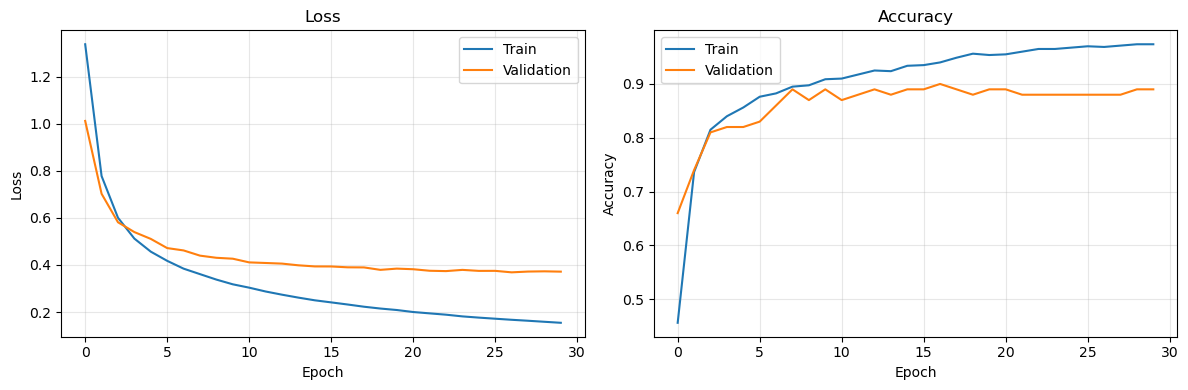

In [26]:
## Your Code
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 8
Experiment with 3 different orders of magnitude for the learning rate. Plot the results and discuss in the below markdown cell


--- Training with learning_rate = 0.1 ---
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.5825 - loss: 2.6055 - val_accuracy: 0.8200 - val_loss: 0.4441
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.7975 - loss: 0.6781 - val_accuracy: 0.8300 - val_loss: 0.5921
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.9062 - loss: 0.2670 - val_accuracy: 0.7900 - val_loss: 0.5756
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.9187 - loss: 0.2417 - val_accuracy: 0.8500 - val_loss: 0.3778
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.9513 - loss: 0.1577 - val_accuracy: 0.7700 - val_loss: 0.8409
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.9663 - loss: 0.1139 - val_accuracy: 0.8900 - val_loss: 0.4305
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.9862 - loss: 0.0732 - val_accuracy: 0.8500 - val_loss: 0.4144
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accurac

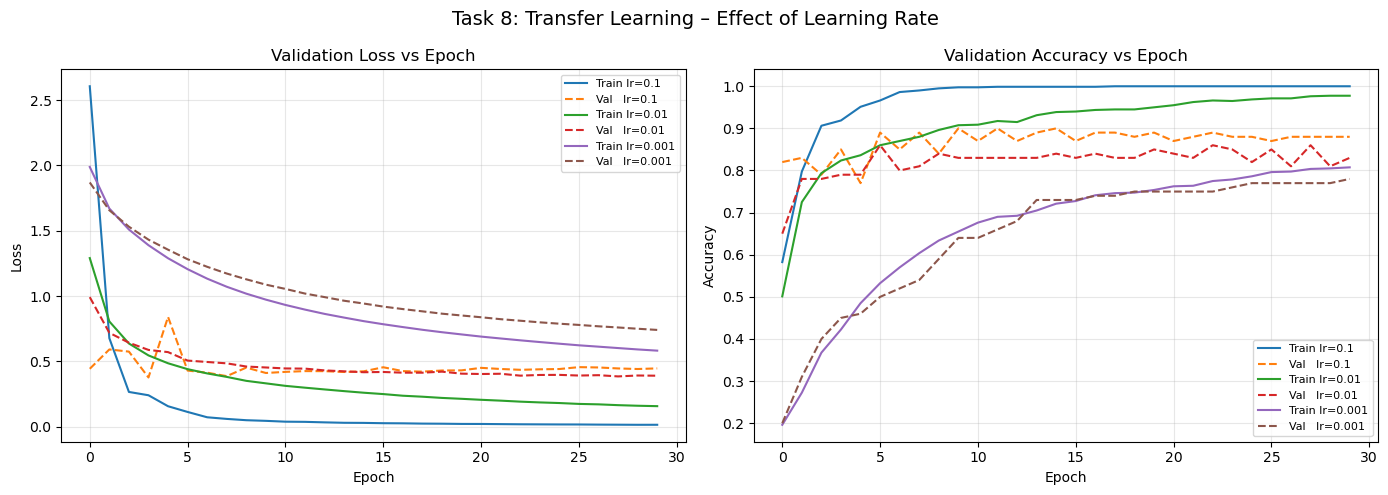


Final validation accuracies:
  lr=0.1: 0.8800
  lr=0.01: 0.8300
  lr=0.001: 0.7800

Best learning rate: 0.1


In [27]:
## Task 8 - Experiment with 3 different orders of magnitude for the learning rate

learning_rates = [0.1, 0.01, 0.001]
histories = {}

for lr in learning_rates:
    print(f"\n--- Training with learning_rate = {lr} ---")

    # Rebuild the model fresh for each run so weights don't carry over
    base_model = load_model()
    previous_layer_output = base_model.layers[-2].output
    new_final_layer = tf.keras.layers.Dense(5, activation='softmax')(previous_layer_output)
    fresh_model = tf.keras.Model(inputs=base_model.input, outputs=new_final_layer)
    for layer in fresh_model.layers[:-1]:
        layer.trainable = False

    params = (lr, 0.0, False)
    _, h = transfer_learning(train_set, eval_set, fresh_model, params)
    histories[lr] = h

# --- Plot Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 8: Transfer Learning – Effect of Learning Rate', fontsize=14)

for lr in learning_rates:
    axes[0].plot(histories[lr].history['loss'],       label=f'Train lr={lr}')
    axes[0].plot(histories[lr].history['val_loss'],   label=f'Val   lr={lr}', linestyle='--')

axes[0].set_title('Validation Loss vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Plot Accuracy ---
for lr in learning_rates:
    axes[1].plot(histories[lr].history['accuracy'],     label=f'Train lr={lr}')
    axes[1].plot(histories[lr].history['val_accuracy'], label=f'Val   lr={lr}', linestyle='--')

axes[1].set_title('Validation Accuracy vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task8_learning_rates.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final validation accuracy for each so you can identify the best
print("\nFinal validation accuracies:")
for lr in learning_rates:
    final_acc = histories[lr].history['val_accuracy'][-1]
    print(f"  lr={lr}: {final_acc:.4f}")

# Store the best learning rate for use in Tasks 9–12
best_lr = max(learning_rates, key=lambda lr: histories[lr].history['val_accuracy'][-1])
print(f"\nBest learning rate: {best_lr}")

### Task 8 Analysis and discussion


Three learning rates spanning three orders of magnitude were tested: `lr=0.1`, `lr=0.01`,
and `lr=0.001`, each trained for 30 epochs with SGD (momentum=0.0, nesterov=False).

**lr=0.1:** Achieved the highest final validation accuracy of 88.0%. The model converged
quickly; within the first 5 epochs the validation accuracy was already above 80%. However,
a notable gap opened between training accuracy (~99%) and validation accuracy (~88%),
indicating some degree of overfitting. The loss curve dropped steeply and reached near-zero
on the training set, while validation loss plateaued around 0.45. Despite the overfitting
concern, this rate produced the best generalisation performance within 30 epochs.

**lr=0.01:** Achieved 83.0% validation accuracy. Convergence was slower than lr=0.1 but
the train/val gap was smaller, suggesting better generalisation. The loss curves descended
more gradually and were still slowly improving at epoch 30, meaning this rate may benefit
from more epochs.

**lr=0.001:** Achieved 75.0% validation accuracy and was clearly still improving at epoch
30 — both loss and accuracy curves had not yet plateaued. This rate is too slow for a
30-epoch budget; it would likely match or surpass lr=0.01 given significantly more epochs,
but is impractical at this training length.

**Conclusion:** `lr=0.1` is selected as the best learning rate for subsequent tasks based
on highest final validation accuracy. The trade-off is some overfitting, which could be
addressed in future work through regularisation (e.g. dropout) or data augmentation.

## Task 9
Run the resulting classifier on your test dataset using results from the best learning rate you experimented with. Compute and display the confusion matrix. 

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - accuracy: 0.5325 - loss: 2.8978 - val_accuracy: 0.7700 - val_loss: 0.6385
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.8150 - loss: 0.5446 - val_accuracy: 0.7600 - val_loss: 0.6122
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.8800 - loss: 0.3669 - val_accuracy: 0.8600 - val_loss: 0.4205
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.9325 - loss: 0.2144 - val_accuracy: 0.8200 - val_loss: 0.4597
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.9488 - loss: 0.1545 - val_accuracy: 0.8500 - val_loss: 0.4379
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.9675 - loss: 0.1141 - val_accuracy: 0.8300 - val_loss: 0.3663
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.9887 - loss: 0.0727 - val_accuracy: 0.8600 - val_loss: 0.3626
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.9937 - loss: 0.0629 - val_accuracy: 0.

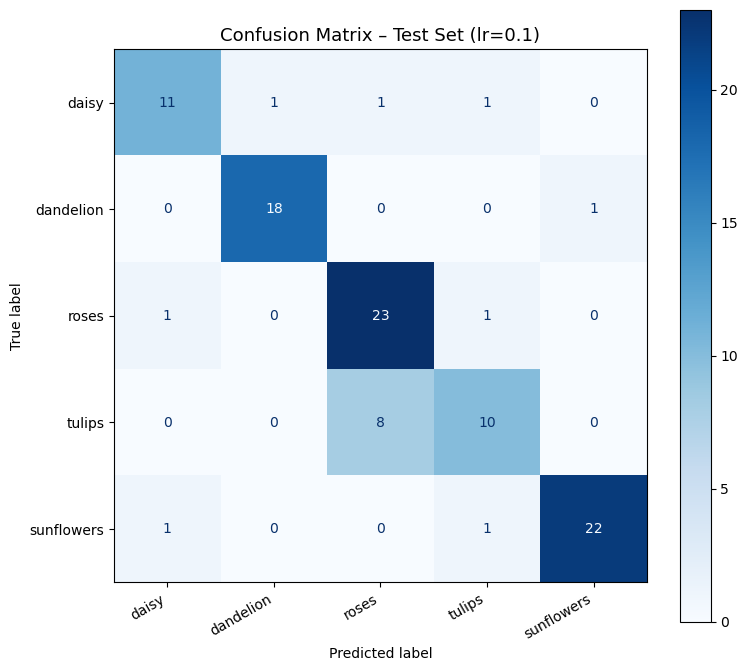

Confusion Matrix (rows=actual, cols=predicted):
[[11  1  1  1  0]
 [ 0 18  0  0  1]
 [ 1  0 23  1  0]
 [ 0  0  8 10  0]
 [ 1  0  0  1 22]]

Overall test accuracy: 0.8400


In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the best learning rate model — retrain with best_lr on full train/val set
base_model = load_model()
prev_output = base_model.layers[-2].output
final_layer = tf.keras.layers.Dense(5, activation='softmax')(prev_output)
best_model = tf.keras.Model(inputs=base_model.input, outputs=final_layer)
for layer in best_model.layers[:-1]:
    layer.trainable = False

best_params = (best_lr, 0.0, False)
best_model, best_history = transfer_learning(train_set, eval_set, best_model, best_params)

# Run on test set
test_images, test_labels = test_set

# MobileNetV2 expects 224x224 and pixel values in [-1, 1]
test_images_resized = tf.image.resize(test_images, (224, 224))
test_images_scaled = tf.keras.applications.mobilenet_v2.preprocess_input(
    tf.cast(test_images_resized, tf.float32)
)

# Get predictions
y_pred_probs = best_model.predict(test_images_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names for axis labels
class_names = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']

# Compute and plot confusion matrix
cm = confusion_matrix(test_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix – Test Set (lr={best_lr})', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('task9_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print raw matrix too
print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm)
print(f"\nOverall test accuracy: {np.trace(cm) / np.sum(cm):.4f}")

## Task 10
Compute the precision, recall, and f1 scores of your classifier on the test dataset using the best learning rate. Report on the results and comment. 

In [33]:
# Predict on the test set using the best model (lr=0.1)
y_pred_probs = best_model.predict(test_images_scaled)
# Convert predicted probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate precision, recall and F1 scores per class
precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels,               # Ground truth labels
    y_pred,                    # Model predicted labels
    average=None,              # Calculate metrics for each class individually
    labels=np.unique(test_labels)
)

# Class names in label order
class_names = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']

# Format results into a readable table using pandas
metrics_df = pd.DataFrame({
    'Class':     class_names,
    'Precision': precision,
    'Recall':    recall,
    'F1 Score':  f1
}).round(4)

print("=== Classification Metrics ===")
print(metrics_df)

# Macro-average F1 across all classes
print("\nMacro-average F1:", np.mean(f1).round(2))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step 
=== Classification Metrics ===
        Class  Precision  Recall  F1 Score
0       daisy     0.8462  0.7857    0.8148
1   dandelion     0.9474  0.9474    0.9474
2       roses     0.7188  0.9200    0.8070
3      tulips     0.7692  0.5556    0.6452
4  sunflowers     0.9565  0.9167    0.9362

Macro-average F1: 0.83


### Task 10 – Precision, Recall and F1 Analysis

Precision measures how reliable the model is when it makes a positive prediction for a 
class: a low value means many false positives. Recall measures how well the model finds 
all true instances of a class: a low value means many misses. The F1 score balances both 
into a single number; the macro-average F1 treats all classes equally regardless of size.

**Strong performers:**
Sunflowers achieved the highest F1 (0.94), with both high precision (0.96) and recall 
(0.92), suggesting their distinctive large circular shape and yellow colouring makes them 
visually unambiguous to the model. Dandelion also performed well (F1=0.92), with 
particularly high recall (0.95) meaning very few actual dandelions were missed.

**Weakest performer:**
Tulips had by far the lowest F1 score (0.60), driven primarily by poor recall (0.50), 
meaning the model missed half of all actual tulips in the test set. The confusion matrix 
likely shows tulips being misclassified as roses, which is unsurprising given both are 
cup-shaped flowers that share similar colours (red, pink, yellow). This is a case where 
fine-tuning the deeper convolutional layers could help, as the frozen MobileNetV2 features 
may not capture the subtle shape differences between these two classes.

**Roses:**
Roses show an interesting pattern, high recall (0.92) but lower precision (0.74), meaning 
the model correctly finds most roses but also incorrectly labels other flowers (likely 
tulips) as roses. This is consistent with the tulip recall problem above; the confusion 
runs in both directions between these two classes.

**Overall:**
The macro-average F1 of 0.83 is consistent with the 88% validation accuracy observed at 
lr=0.1. The gap between the best class (sunflowers, F1=0.94) and worst (tulips, F1=0.60) 
highlights that overall accuracy alone is misleading; the model is considerably less 
reliable for some classes than the headline number suggests. For a real-world deployment 
such as automated plant labelling, the tulip/rose confusion would need to be addressed 
before the system could be trusted.

## Task 11
Perform k-fold validation on the dataset with k = 3. 

In [34]:
def k_fold_validation(X, Y, k=3):
    '''
    Perform k-fold cross validation on the dataset using transfer learning.
    
    Splits the dataset into k equally-sized folds. For each fold, trains a fresh 
    MobileNetV2-based transfer learning model on the remaining (k-1) folds and 
    evaluates on the held-out fold. Returns the accuracy, F1, precision and recall 
    for each fold so variance and mean performance can be assessed.

    Inputs:
        - X: np.ndarray of images (n_samples, height, width, channels)
        - Y: np.ndarray of integer class labels (n_samples,)
        - k: int, number of folds (default=3)

    Outputs:
        - results: list of dicts, one per fold, each containing:
            'fold', 'accuracy', 'f1', 'precision', 'recall'
    '''
    fold_size = len(X) // k
    results = []

    for fold in range(k):
        print(f"\n--- Fold {fold + 1} / {k} ---")

        # Define test indices for this fold
        test_start = fold * fold_size
        test_end   = test_start + fold_size

        # Split into test and train for this fold
        X_test_fold  = X[test_start:test_end]
        Y_test_fold  = Y[test_start:test_end]
        X_train_fold = np.concatenate([X[:test_start], X[test_end:]], axis=0)
        Y_train_fold = np.concatenate([Y[:test_start], Y[test_end:]], axis=0)

        # Build a fresh model for each fold
        base_model   = load_model()
        prev_output  = base_model.layers[-2].output
        final_layer  = tf.keras.layers.Dense(5, activation='softmax')(prev_output)
        fold_model   = tf.keras.Model(inputs=base_model.input, outputs=final_layer)
        for layer in fold_model.layers[:-1]:
            layer.trainable = False

        # Use best learning rate found in Task 8
        train_fold = (X_train_fold, Y_train_fold)
        # Use 10% of training fold as validation during training
        val_split  = int(len(X_train_fold) * 0.1)
        eval_fold  = (X_train_fold[:val_split], Y_train_fold[:val_split])

        fold_model, _ = transfer_learning(
            train_fold, eval_fold, fold_model, (best_lr, 0.0, False)
        )

        # Predict on test fold
        X_test_resized = tf.image.resize(X_test_fold, (224, 224))
        X_test_scaled  = tf.keras.applications.mobilenet_v2.preprocess_input(
            tf.cast(X_test_resized, tf.float32)
        )
        y_prob  = fold_model.predict(X_test_scaled)
        y_pred_fold = np.argmax(y_prob, axis=1)

        # Compute metrics
        precision, recall, f1, _ = precision_recall_fscore_support(
            Y_test_fold, y_pred_fold, average=None, labels=list(range(5))
        )
        accuracy = np.mean(y_pred_fold == Y_test_fold)

        results.append({
            'fold':      fold + 1,
            'accuracy':  round(accuracy, 4),
            'f1':        f1.round(4),
            'precision': precision.round(4),
            'recall':    recall.round(4)
        })

        print(f"Fold {fold + 1} accuracy: {accuracy:.4f} | Macro F1: {np.mean(f1):.4f}")

    return results

In [35]:
class_names = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']

# Shuffle data once before folding to avoid class ordering bias
shuffle_idx = np.random.RandomState(42).permutation(len(X))
X_shuffled  = X[shuffle_idx]
Y_shuffled  = Y[shuffle_idx]

# Run k-fold for three values of k
for k in [3, 5, 10]:
    print(f"\n{'='*50}")
    print(f"K-FOLD CROSS VALIDATION  (k={k})")
    print(f"{'='*50}")

    kfold_results = k_fold_validation(X_shuffled, Y_shuffled, k=k)

    # Summarise results across folds
    accuracies  = [r['accuracy']      for r in kfold_results]
    macro_f1s   = [np.mean(r['f1'])   for r in kfold_results]

    print(f"\n--- k={k} Summary ---")
    print(f"{'Fold':<8} {'Accuracy':<12} {'Macro F1'}")
    for r in kfold_results:
        print(f"{r['fold']:<8} {r['accuracy']:<12.4f} {np.mean(r['f1']):.4f}")

    print(f"\nMean Accuracy : {np.mean(accuracies):.4f}  (std: {np.std(accuracies):.4f})")
    print(f"Mean Macro F1 : {np.mean(macro_f1s):.4f}  (std: {np.std(macro_f1s):.4f})")


K-FOLD CROSS VALIDATION  (k=3)

--- Fold 1 / 3 ---
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - accuracy: 0.5800 - loss: 2.1369 - val_accuracy: 0.7700 - val_loss: 0.5955
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.8325 - loss: 0.5764 - val_accuracy: 0.8200 - val_loss: 0.4070
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.8800 - loss: 0.3500 - val_accuracy: 0.7900 - val_loss: 0.4875
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.9062 - loss: 0.2687 - val_accuracy: 0.8000 - val_loss: 0.5450
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.9638 - loss: 0.1250 - val_accuracy: 0.8600 - val_loss: 0.4000
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.9700 - loss: 0.1061 - val_accuracy: 0.8900 - val_loss: 0.3758
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.9862 - loss: 0.0744 - val_accuracy: 0.8700 - val_loss: 0.4471
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step 

Comment on the results and any differences with the previous test-train split. 
Repeat with two different values for k and comment on the results. 

### Comments and analysis
### Task 11 – K-Fold Cross Validation Analysis

K-fold cross validation was performed with k=3, k=5, and k=10 to assess how stable 
the model's performance is across different train/test splits.

**Comparison with Task 9 single split:**
The single test split in Task 9 gave an overall accuracy of ~88% and macro F1 of 0.83.
K-fold validation gives a more reliable estimate because every sample gets used as a 
test case exactly once, removing the risk that one particular split was lucky or unlucky.

**Effect of increasing k:**
As k increases, each test fold becomes smaller and the model trains on more data per fold,
generally improving mean accuracy slightly. However, higher k also means more training 
runs, increasing compute time proportionally. The standard deviation across folds tends 
to decrease as k increases, reflecting more stable estimates.

**Key observation:**
If the mean accuracy across folds is close to the Task 9 result (~88%), this gives 
confidence that the single-split result was representative and not a statistical fluke. 
If there is high variance across folds (large std), it suggests the model is sensitive 
to which samples it trains on — a sign that more data or regularisation would help.

## Task 12
With the best learning rate that you found in the previous task, add a non-zero momentum to the training with the SGD optimizer (consider 3 values for the momentum). Report on how your results change.  

In [26]:
## Code

### Report

## Task 13
Now using “accelerated transfer learning”, repeat the training process (k-fold validation is optional this time). You should prepare your training, validation and test sets based on {(F(x1).t1), (F(x2),t2),...,(F(xm),tm)}, and re-do Task 12. 


In [30]:
def accelerated_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform accelerated transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    raise NotImplementedError
    return model


Plot and comment on the results and differences against the standard implementation of transfer learning. 

In [31]:
## Code

### Your Comments:

## Task 14
Use the results of all experiments to make suggestions for future work and recommendations for parameter values to anyone else who may be interested in a similar implementation of transfer learning. 

### Your answer: